In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import (
    fligner,
    jarque_bera,
    kurtosis,
    ks_2samp,
    skew,
)
from statsmodels.tsa.stattools import zivot_andrews

In [3]:
DATA_FILE = Path("IRESS DATASET.xlsx")

BANK_MAP = {
    "STANDARD BANK GROUP LTD": "StandardBank",
    "FIRSTRAND LTD": "FirstRand",
    "ABSA GROUP LTD": "Absa",
    "NEDBANK GROUP LTD": "Nedbank",
    "CAPITEC BANK HOLDINGS LTD": "Capitec",
}

DISPLAY_NAMES = {
    "StandardBank": "Standard Bank",
    "FirstRand": "FirstRand",
    "Absa": "Absa",
    "Nedbank": "Nedbank",
    "Capitec": "Capitec",
}

BANKS = list(BANK_MAP.values())

MAX_BREAKS = 5
MIN_REGIME_SIZE = 120
ICSS_CRITICAL_VALUE = 1.358
PLACEBO_SIMULATIONS = 5000
RANDOM_SEED = 20260717
SIGNIFICANCE_LEVEL = 0.05

In [5]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"{DATA_FILE} was not found. Place the workbook in the same folder "
        "as this notebook."
    )

raw_data = pd.read_excel(DATA_FILE)

required_columns = ["Date"] + list(BANK_MAP.keys())
missing_columns = [
    column for column in required_columns
    if column not in raw_data.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

data = (
    raw_data[required_columns]
    .rename(columns=BANK_MAP)
    .copy()
)

data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

for bank in BANKS:
    data[bank] = pd.to_numeric(data[bank], errors="coerce")

data = (
    data
    .dropna(subset=["Date"])
    .sort_values("Date")
    .drop_duplicates(subset="Date")
    .set_index("Date")
)

if data[BANKS].isna().any().any():
    missing = data[BANKS].isna().sum()
    raise ValueError(
        "Missing or non-numeric price observations were detected:\n"
        f"{missing[missing > 0]}"
    )

prices = data[BANKS]
returns = (100 * np.log(prices / prices.shift(1))).dropna()
absolute_returns = returns.abs()
squared_returns = returns.pow(2)

print(f"Price observations per bank: {len(prices)}")
print(f"Return observations per bank: {len(returns)}")
print(
    f"Sample period: {prices.index.min().date()} "
    f"to {prices.index.max().date()}"
)

display(prices.head())
display(returns.head())

Price observations per bank: 2496
Return observations per bank: 2495
Sample period: 2016-01-27 to 2026-01-23


,StandardBank,FirstRand,Absa,Nedbank,Capitec
Date,,,,,
2016-01-27,10380,4050,13144,17500,43995
2016-01-28,10700,4219,13700,18300,45300
2016-01-29,11221,4472,14396,18744,48100
2016-02-01,11084,4449,14250,18548,46897
2016-02-02,10480,4190,13681,17900,45388


,StandardBank,FirstRand,Absa,Nedbank,Capitec
Date,,,,,
2016-01-28,3.036286,4.088125,4.143045,4.470018,2.923104
2016-01-29,4.754328,5.823760,4.955456,2.397264,5.997514
2016-02-01,-1.228440,-0.515638,-1.019348,-1.051173,-2.532847
2016-02-02,-5.603395,-5.997862,-4.074890,-3.556125,-3.270595
2016-02-03,-0.286670,-0.047744,0.495809,0.239935,0.026435


In [7]:
descriptive_rows = []

for bank in BANKS:
    values = returns[bank].to_numpy()
    jb_result = jarque_bera(values)

    descriptive_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "Observations": len(values),
        "Mean": np.mean(values),
        "Standard deviation": np.std(values, ddof=1),
        "Minimum": np.min(values),
        "Maximum": np.max(values),
        "Skewness": skew(values, bias=False),
        "Excess kurtosis": kurtosis(
            values,
            fisher=True,
            bias=False,
        ),
        "Jarque-Bera statistic": jb_result.statistic,
        "Jarque-Bera p-value": jb_result.pvalue,
    })

descriptive_table = pd.DataFrame(descriptive_rows)

numeric_columns = descriptive_table.columns.drop(
    ["Bank", "Observations"]
)

descriptive_table[numeric_columns] = (
    descriptive_table[numeric_columns].round(4)
)

display(descriptive_table)

,Bank,Observations,Mean,Standard deviation,Minimum,Maximum,Skewness,Excess kurtosis,Jarque-Bera statistic,Jarque-Bera p-value
0,Standard Bank,2495,0.0420,1.9773,-13.6465,11.7015,-0.1860,4.4366,2050.2174,0.0
1,FirstRand,2495,0.0326,1.9935,-15.4073,12.9060,-0.1441,4.6555,2250.4370,0.0
2,Absa,2495,0.0257,2.1512,-16.8912,16.9603,-0.2035,6.7723,4762.7383,0.0
3,Nedbank,2495,0.0179,2.1546,-17.1716,12.8139,-0.3158,7.5577,5951.8285,0.0
4,Capitec,2495,0.0919,2.1589,-32.7413,35.1771,-0.1792,55.0519,313793.0190,0.0


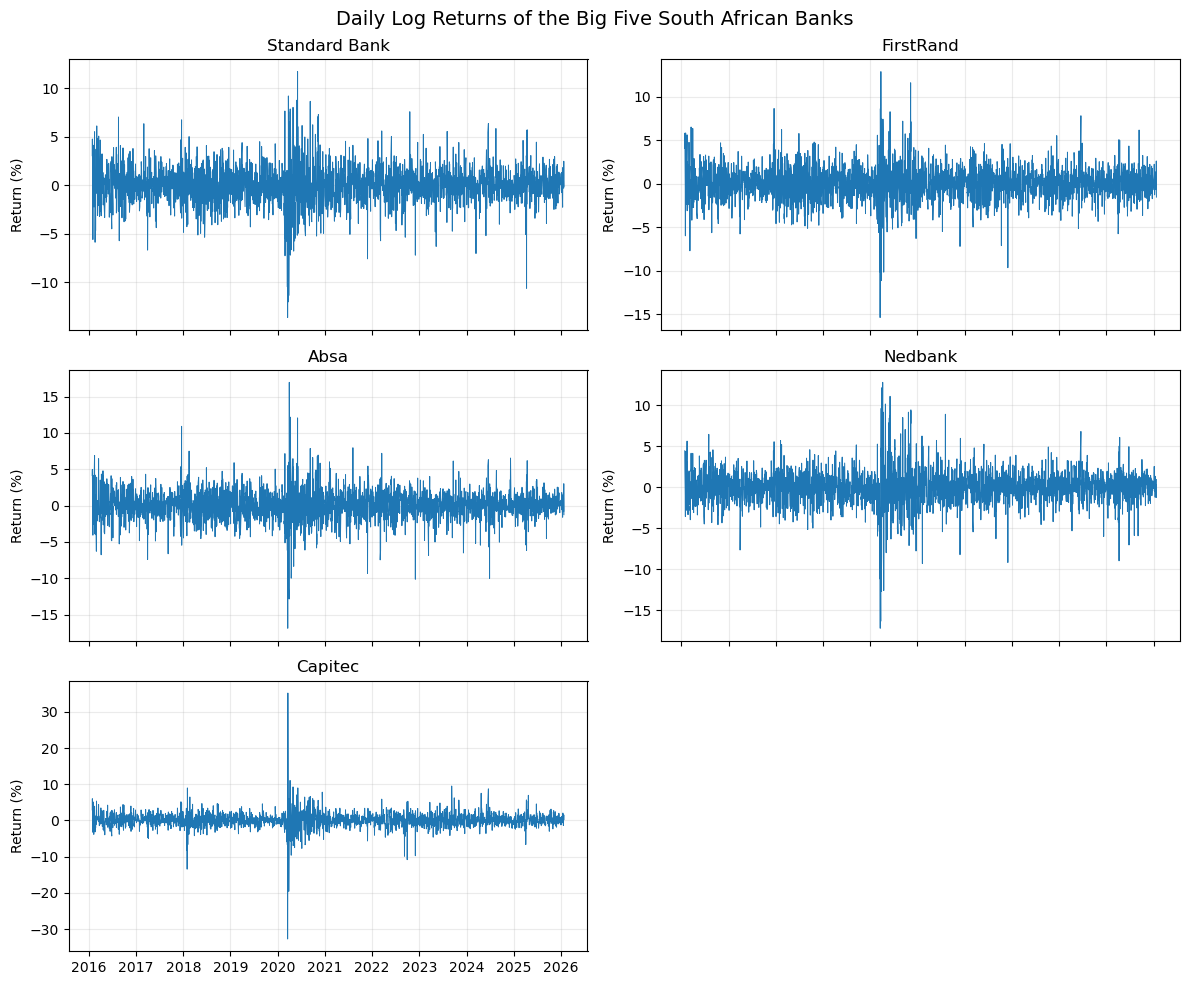

In [9]:
figure, axes = plt.subplots(
    3,
    2,
    figsize=(12, 10),
    sharex=True,
)

axes = axes.flatten()

for axis, bank in zip(axes, BANKS):
    axis.plot(
        returns.index,
        returns[bank],
        linewidth=0.7,
    )

    axis.set_title(DISPLAY_NAMES[bank])
    axis.set_ylabel("Return (%)")
    axis.grid(alpha=0.25)

axes[-1].axis("off")

figure.suptitle(
    "Daily Log Returns of the Big Five South African Banks",
    fontsize=14,
)

plt.tight_layout()
plt.show()

In [11]:
zivot_rows = []

for bank in BANKS:
    statistic, p_value, critical_values, lag, break_index = (
        zivot_andrews(
            returns[bank],
            regression="c",
            autolag="AIC",
        )
    )

    zivot_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "Test statistic": statistic,
        "p-value": p_value,
        "Break date": returns.index[break_index].strftime("%Y-%m-%d"),
        "Lag": lag,
        "Decision": (
            "Reject unit-root null"
            if p_value < SIGNIFICANCE_LEVEL
            else "Do not reject unit-root null"
        ),
    })

zivot_table = pd.DataFrame(zivot_rows)

zivot_table["Test statistic"] = (
    zivot_table["Test statistic"].round(4)
)

zivot_table["p-value"] = (
    zivot_table["p-value"].round(4)
)

display(zivot_table)

,Bank,Test statistic,p-value,Break date,Lag,Decision
0,Standard Bank,-13.8919,0.0,2020-05-14,14,Reject unit-root null
1,FirstRand,-11.8315,0.0,2020-09-03,20,Reject unit-root null
2,Absa,-18.6595,0.0,2020-03-30,8,Reject unit-root null
3,Nedbank,-14.2328,0.0,2020-05-14,15,Reject unit-root null
4,Capitec,-10.2145,0.0,2023-06-01,27,Reject unit-root null


In [13]:
def estimate_breaks(
    series,
    max_breaks=MAX_BREAKS,
    minimum_size=MIN_REGIME_SIZE,
):
    values = series.dropna().to_numpy(dtype=float)
    dates = series.dropna().index
    n = len(values)

    cumulative_sum = np.concatenate([
        [0.0],
        np.cumsum(values),
    ])

    cumulative_sum_squares = np.concatenate([
        [0.0],
        np.cumsum(values ** 2),
    ])

    def segment_sse(start, end):
        length = end - start
        total = cumulative_sum[end] - cumulative_sum[start]
        total_squares = (
            cumulative_sum_squares[end]
            - cumulative_sum_squares[start]
        )

        return total_squares - total ** 2 / length

    models = []

    for number_of_breaks in range(max_breaks + 1):
        number_of_segments = number_of_breaks + 1

        if number_of_segments * minimum_size > n:
            continue

        costs = np.full(
            (number_of_segments + 1, n + 1),
            np.inf,
        )

        previous = np.full(
            (number_of_segments + 1, n + 1),
            -1,
            dtype=int,
        )

        costs[0, 0] = 0.0

        for segment_number in range(
            1,
            number_of_segments + 1,
        ):
            earliest_end = (
                segment_number * minimum_size
            )

            for end in range(
                earliest_end,
                n + 1,
            ):
                earliest_start = (
                    (segment_number - 1)
                    * minimum_size
                )

                latest_start = end - minimum_size

                for start in range(
                    earliest_start,
                    latest_start + 1,
                ):
                    candidate_cost = (
                        costs[
                            segment_number - 1,
                            start,
                        ]
                        + segment_sse(start, end)
                    )

                    if candidate_cost < costs[
                        segment_number,
                        end,
                    ]:
                        costs[
                            segment_number,
                            end,
                        ] = candidate_cost

                        previous[
                            segment_number,
                            end,
                        ] = start

        residual_sum_of_squares = costs[
            number_of_segments,
            n,
        ]

        if not np.isfinite(residual_sum_of_squares):
            continue

        break_indices = []
        end = n

        for segment_number in range(
            number_of_segments,
            0,
            -1,
        ):
            start = previous[
                segment_number,
                end,
            ]

            if segment_number > 1:
                break_indices.append(start)

            end = start

        break_indices.sort()

        parameter_count = 2 * number_of_breaks + 1

        bic = (
            n * np.log(
                residual_sum_of_squares / n
            )
            + parameter_count * np.log(n)
        )

        models.append({
            "Number of breaks": number_of_breaks,
            "RSS": residual_sum_of_squares,
            "BIC": bic,
            "Break indices": break_indices,
            "Break dates": [
                dates[index]
                for index in break_indices
            ],
        })

    selected_model = min(
        models,
        key=lambda model: model["BIC"],
    )

    return selected_model, models

In [15]:
absolute_models = {}
squared_models = {}

absolute_rows = []
squared_rows = []
bic_rows = []

for bank in BANKS:
    absolute_model, absolute_candidates = estimate_breaks(
        absolute_returns[bank]
    )

    squared_model, squared_candidates = estimate_breaks(
        squared_returns[bank]
    )

    absolute_models[bank] = absolute_model
    squared_models[bank] = squared_model

    absolute_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "Series": "Absolute returns",
        "Breaks": absolute_model["Number of breaks"],
        "BIC": absolute_model["BIC"],
        "Break dates": "; ".join(
            date.strftime("%Y-%m-%d")
            for date in absolute_model["Break dates"]
        ),
    })

    squared_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "Series": "Squared returns",
        "Breaks": squared_model["Number of breaks"],
        "BIC": squared_model["BIC"],
        "Break dates": "; ".join(
            date.strftime("%Y-%m-%d")
            for date in squared_model["Break dates"]
        ),
    })

    for model in absolute_candidates:
        bic_rows.append({
            "Bank": DISPLAY_NAMES[bank],
            "Series": "Absolute returns",
            "Number of breaks": model["Number of breaks"],
            "BIC": model["BIC"],
        })

    for model in squared_candidates:
        bic_rows.append({
            "Bank": DISPLAY_NAMES[bank],
            "Series": "Squared returns",
            "Number of breaks": model["Number of breaks"],
            "BIC": model["BIC"],
        })

absolute_breaks_table = pd.DataFrame(absolute_rows)
squared_breaks_table = pd.DataFrame(squared_rows)
bic_table = pd.DataFrame(bic_rows)

absolute_breaks_table["BIC"] = (
    absolute_breaks_table["BIC"].round(4)
)

squared_breaks_table["BIC"] = (
    squared_breaks_table["BIC"].round(4)
)

bic_table["BIC"] = bic_table["BIC"].round(4)

print("Absolute-return breaks")
display(absolute_breaks_table)

print("Squared-return breaks")
display(squared_breaks_table)

Absolute-return breaks


,Bank,Series,Breaks,BIC,Break dates
0,Standard Bank,Absolute returns,3,1370.2139,2016-10-03; 2020-02-20; 2020-12-01
1,FirstRand,Absolute returns,5,1408.3867,2016-12-19; 2017-12-08; 2018-11-14; 2020-02-21...
2,Absa,Absolute returns,4,1852.2596,2016-07-22; 2020-02-26; 2020-11-12; 2022-07-22
3,Nedbank,Absolute returns,3,1793.2125,2020-02-26; 2020-11-12; 2021-08-25
4,Capitec,Absolute returns,4,2318.7357,2017-12-05; 2018-07-05; 2020-03-12; 2020-09-14


Squared-return breaks


,Bank,Series,Breaks,BIC,Break dates
0,Standard Bank,Squared returns,3,11161.8257,2020-02-20; 2020-08-14; 2021-02-08
1,FirstRand,Squared returns,2,11423.7592,2020-02-24; 2020-11-16
2,Absa,Squared returns,2,12834.3119,2020-03-16; 2020-09-11
3,Nedbank,Squared returns,3,12900.1191,2020-03-16; 2020-09-11; 2021-03-04
4,Capitec,Squared returns,2,17670.9195,2020-03-12; 2020-09-04


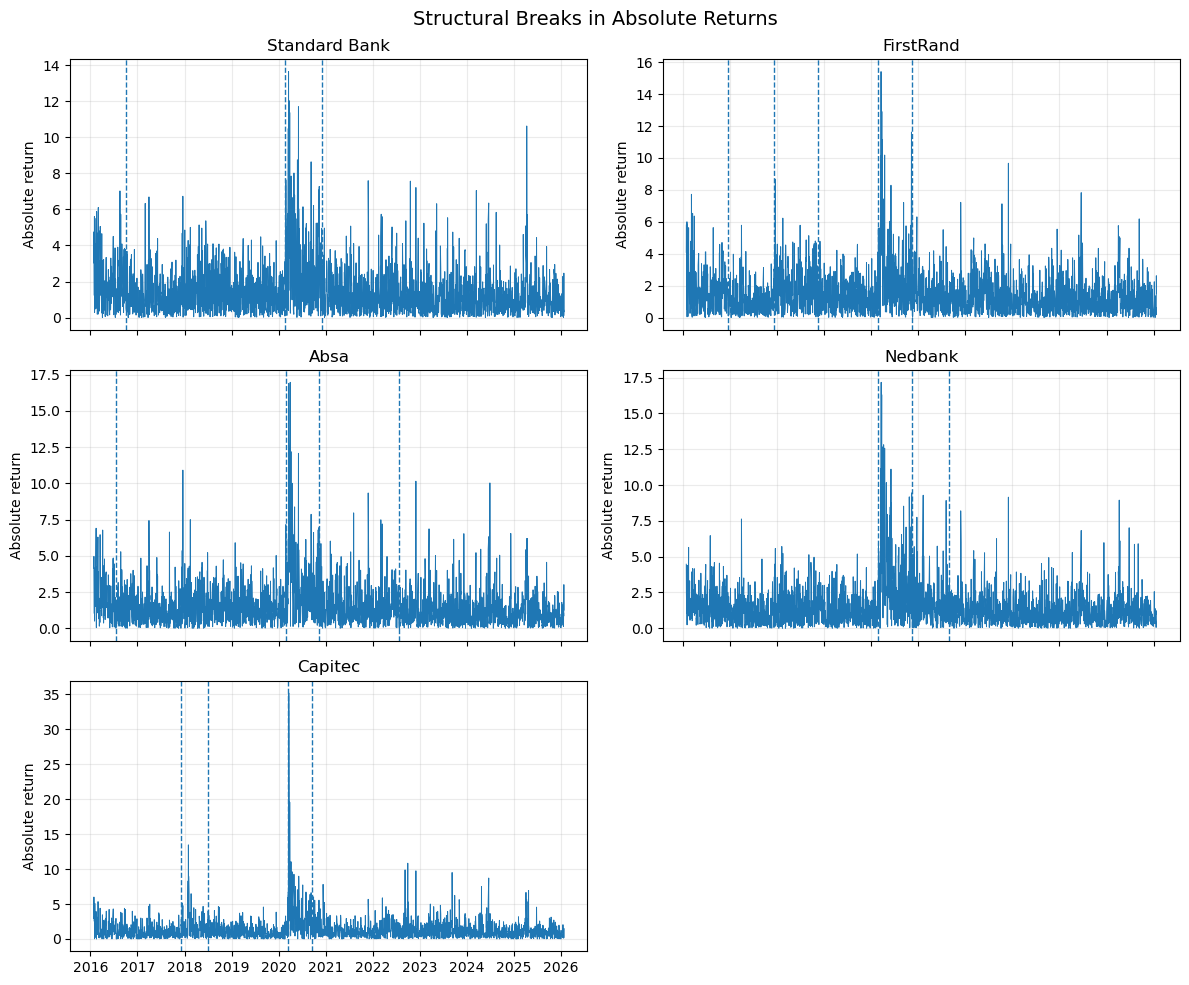

In [16]:
figure, axes = plt.subplots(
    3,
    2,
    figsize=(12, 10),
    sharex=True,
)

axes = axes.flatten()

for axis, bank in zip(axes, BANKS):
    axis.plot(
        absolute_returns.index,
        absolute_returns[bank],
        linewidth=0.7,
    )

    for break_date in absolute_models[bank]["Break dates"]:
        axis.axvline(
            break_date,
            linestyle="--",
            linewidth=1,
        )

    axis.set_title(DISPLAY_NAMES[bank])
    axis.set_ylabel("Absolute return")
    axis.grid(alpha=0.25)

axes[-1].axis("off")

figure.suptitle(
    "Structural Breaks in Absolute Returns",
    fontsize=14,
)

plt.tight_layout()
plt.show()

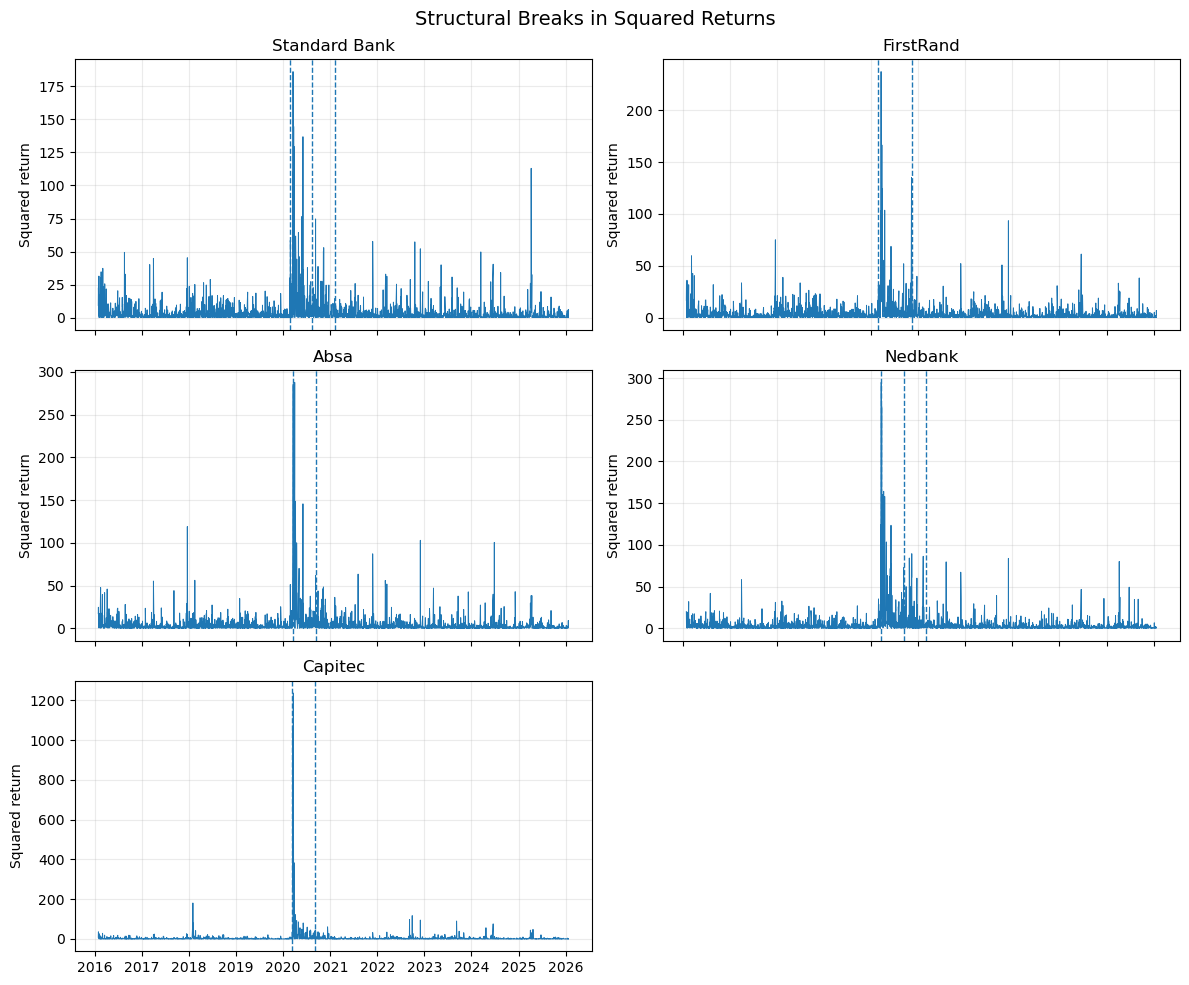

In [17]:
figure, axes = plt.subplots(
    3,
    2,
    figsize=(12, 10),
    sharex=True,
)

axes = axes.flatten()

for axis, bank in zip(axes, BANKS):
    axis.plot(
        squared_returns.index,
        squared_returns[bank],
        linewidth=0.7,
    )

    for break_date in squared_models[bank]["Break dates"]:
        axis.axvline(
            break_date,
            linestyle="--",
            linewidth=1,
        )

    axis.set_title(DISPLAY_NAMES[bank])
    axis.set_ylabel("Squared return")
    axis.grid(alpha=0.25)

axes[-1].axis("off")

figure.suptitle(
    "Structural Breaks in Squared Returns",
    fontsize=14,
)

plt.tight_layout()
plt.show()

In [30]:
factor_model_rows = []
factor_break_rows = []
factor_residuals = {}

FACTOR_TRIM = 0.15
factor_minimum_size = int(np.floor(FACTOR_TRIM * len(returns)))

for bank in BANKS:
    other_banks = [
        other_bank
        for other_bank in BANKS
        if other_bank != bank
    ]

    common_factor = returns[other_banks].mean(axis=1)

    X = np.column_stack([
        np.ones(len(common_factor)),
        common_factor.to_numpy(),
    ])

    y = returns[bank].to_numpy()

    alpha, beta = np.linalg.lstsq(
        X,
        y,
        rcond=None,
    )[0]

    fitted_values = X @ np.array([alpha, beta])

    residuals = pd.Series(
        y - fitted_values,
        index=returns.index,
        name=bank,
    )

    factor_residuals[bank] = residuals

    residual_sum_of_squares = np.sum(
        residuals.to_numpy() ** 2
    )

    total_sum_of_squares = np.sum(
        (y - np.mean(y)) ** 2
    )

    r_squared = (
        1
        - residual_sum_of_squares
        / total_sum_of_squares
    )

    factor_model_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "Alpha": alpha,
        "Beta": beta,
        "R-squared": r_squared,
    })

    absolute_residual_model, _ = estimate_breaks(
        residuals.abs(),
        max_breaks=MAX_BREAKS,
        minimum_size=factor_minimum_size,
    )

    squared_residual_model, _ = estimate_breaks(
        residuals.pow(2),
        max_breaks=MAX_BREAKS,
        minimum_size=factor_minimum_size,
    )

    factor_break_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "Series": "Absolute residuals",
        "Breaks": absolute_residual_model[
            "Number of breaks"
        ],
        "Break dates": "; ".join(
            date.strftime("%Y-%m-%d")
            for date in absolute_residual_model[
                "Break dates"
            ]
        ) or "None",
    })

    factor_break_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "Series": "Squared residuals",
        "Breaks": squared_residual_model[
            "Number of breaks"
        ],
        "Break dates": "; ".join(
            date.strftime("%Y-%m-%d")
            for date in squared_residual_model[
                "Break dates"
            ]
        ) or "None",
    })

factor_models_table = pd.DataFrame(
    factor_model_rows
)

factor_breaks_table = pd.DataFrame(
    factor_break_rows
)

factor_models_table[
    ["Alpha", "Beta", "R-squared"]
] = factor_models_table[
    ["Alpha", "Beta", "R-squared"]
].round(4)

print(
    f"Common-factor minimum regime size: "
    f"{factor_minimum_size} observations"
)

print("\nCommon banking-factor regressions")
display(factor_models_table)

print("\nBreaks in common-factor-adjusted residual returns")
display(factor_breaks_table)

Common-factor minimum regime size: 374 observations

Common banking-factor regressions


,Bank,Alpha,Beta,R-squared
0,Standard Bank,0.0000,0.9882,0.7275
1,FirstRand,-0.0001,0.9516,0.6829
2,Absa,-0.0002,0.9524,0.6837
3,Nedbank,-0.0003,0.9487,0.6792
4,Capitec,0.0007,0.6790,0.3837



Breaks in common-factor-adjusted residual returns


,Bank,Series,Breaks,Break dates
0,Standard Bank,Absolute residuals,2,2020-02-24; 2021-08-31
1,Standard Bank,Squared residuals,2,2020-02-24; 2021-08-25
2,FirstRand,Absolute residuals,2,2020-03-04; 2021-09-07
3,FirstRand,Squared residuals,2,2020-03-06; 2021-09-07
4,Absa,Absolute residuals,2,2020-03-05; 2021-09-02
5,Absa,Squared residuals,2,2020-03-05; 2021-09-02
6,Nedbank,Absolute residuals,2,2020-02-24; 2021-08-23
7,Nedbank,Squared residuals,2,2020-02-24; 2021-08-23
8,Capitec,Absolute residuals,2,2020-02-26; 2021-08-26
9,Capitec,Squared residuals,0,None


In [31]:
def robust_icss_test(series):
    values = series.dropna().to_numpy(dtype=float)
    n = len(values)

    centred_returns = values - np.mean(values)
    estimated_variance = np.mean(centred_returns ** 2)

    centred_squared_returns = (
        centred_returns ** 2
        - estimated_variance
    )

    bandwidth = max(
        1,
        int(
            np.floor(
                12 * (n / 100) ** 0.25
            )
        ),
    )

    long_run_variance = (
        np.dot(
            centred_squared_returns,
            centred_squared_returns,
        )
        / n
    )

    for lag in range(1, bandwidth + 1):
        autocovariance = (
            np.dot(
                centred_squared_returns[lag:],
                centred_squared_returns[:-lag],
            )
            / n
        )

        weight = (
            1
            - lag / (bandwidth + 1)
        )

        long_run_variance += (
            2 * weight * autocovariance
        )

    long_run_variance = max(
        long_run_variance,
        1e-12,
    )

    cumulative_deviation = np.cumsum(
        centred_squared_returns
    )

    statistic_path = (
        np.abs(cumulative_deviation)
        / np.sqrt(
            n * long_run_variance
        )
    )

    candidate_index = int(
        np.argmax(statistic_path)
    )

    statistic = statistic_path[
        candidate_index
    ]

    return {
        "Statistic": statistic,
        "Candidate index": candidate_index,
        "Bandwidth": bandwidth,
        "Reject": (
            statistic
            > ICSS_CRITICAL_VALUE
        ),
    }

In [32]:
icss_rows = []

for bank in BANKS:
    result = robust_icss_test(
        returns[bank]
    )

    icss_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "Kappa-squared statistic": result["Statistic"],
        "Critical value": ICSS_CRITICAL_VALUE,
        "Candidate date": returns.index[
            result["Candidate index"]
        ].strftime("%Y-%m-%d"),
        "Decision": (
            "Reject variance stability"
            if result["Reject"]
            else "Do not reject variance stability"
        ),
    })

icss_table = pd.DataFrame(icss_rows)

icss_table[
    "Kappa-squared statistic"
] = icss_table[
    "Kappa-squared statistic"
].round(4)

display(icss_table)

,Bank,Kappa-squared statistic,Critical value,Candidate date,Decision
0,Standard Bank,1.3333,1.358,2020-12-21,Do not reject variance stability
1,FirstRand,1.3039,1.358,2021-01-11,Do not reject variance stability
2,Absa,1.1039,1.358,2020-11-30,Do not reject variance stability
3,Nedbank,1.1102,1.358,2021-02-12,Do not reject variance stability
4,Capitec,0.7487,1.358,2020-12-21,Do not reject variance stability


In [33]:
regime_rows = []

for bank in BANKS:
    ks_significant = 0
    variance_significant = 0
    total_significant = 0

    for selected_model in [
        absolute_models[bank],
        squared_models[bank],
    ]:
        boundaries = (
            [0]
            + selected_model["Break indices"]
            + [len(returns)]
        )

        for regime_number in range(
            len(boundaries) - 2
        ):
            start_1 = boundaries[
                regime_number
            ]

            end_1 = boundaries[
                regime_number + 1
            ]

            start_2 = end_1

            end_2 = boundaries[
                regime_number + 2
            ]

            regime_1 = returns[
                bank
            ].iloc[start_1:end_1]

            regime_2 = returns[
                bank
            ].iloc[start_2:end_2]

            ks_p_value = ks_2samp(
                regime_1,
                regime_2,
            ).pvalue

            variance_p_value = fligner(
                regime_1,
                regime_2,
            ).pvalue

            ks_reject = (
                ks_p_value
                < SIGNIFICANCE_LEVEL
            )

            variance_reject = (
                variance_p_value
                < SIGNIFICANCE_LEVEL
            )

            ks_significant += int(
                ks_reject
            )

            variance_significant += int(
                variance_reject
            )

            total_significant += int(
                ks_reject
                or variance_reject
            )

    regime_rows.append({
        "Bank": DISPLAY_NAMES[bank],
        "KS significant": ks_significant,
        "Variance significant": variance_significant,
        "Total significant comparisons": total_significant,
    })

regime_table = pd.DataFrame(regime_rows)

display(regime_table)

,Bank,KS significant,Variance significant,Total significant comparisons
0,Standard Bank,4,6,6
1,FirstRand,7,7,7
2,Absa,5,6,6
3,Nedbank,6,6,6
4,Capitec,6,6,6


In [34]:
def between_regime_sum_of_squares(
    values,
    break_indices,
):
    values = np.asarray(values, dtype=float)

    boundaries = (
        [0]
        + list(break_indices)
        + [len(values)]
    )

    overall_mean = np.mean(values)
    statistic = 0.0

    for start, end in zip(
        boundaries[:-1],
        boundaries[1:],
    ):
        segment = values[start:end]

        statistic += (
            len(segment)
            * (
                np.mean(segment)
                - overall_mean
            ) ** 2
        )

    return statistic

In [35]:
random_generator = np.random.default_rng(
    RANDOM_SEED
)

placebo_rows = []

analysis_sets = [
    (
        "Absolute returns",
        absolute_returns,
        absolute_models,
    ),
    (
        "Squared returns",
        squared_returns,
        squared_models,
    ),
]

for series_name, transformed_data, models in analysis_sets:
    for bank in BANKS:
        values = transformed_data[
            bank
        ].to_numpy()

        selected_model = models[bank]
        number_of_breaks = selected_model[
            "Number of breaks"
        ]

        observed_bss = (
            between_regime_sum_of_squares(
                values,
                selected_model[
                    "Break indices"
                ],
            )
        )

        simulated_bss = []

        for _ in range(
            PLACEBO_SIMULATIONS
        ):
            while True:
                candidate_breaks = np.sort(
                    random_generator.choice(
                        np.arange(
                            MIN_REGIME_SIZE,
                            len(values)
                            - MIN_REGIME_SIZE
                            + 1,
                        ),
                        size=number_of_breaks,
                        replace=False,
                    )
                )

                boundaries = np.concatenate([
                    [0],
                    candidate_breaks,
                    [len(values)],
                ])

                if np.all(
                    np.diff(boundaries)
                    >= MIN_REGIME_SIZE
                ):
                    break

            simulated_bss.append(
                between_regime_sum_of_squares(
                    values,
                    candidate_breaks,
                )
            )

        simulated_bss = np.asarray(
            simulated_bss
        )

        placebo_p_value = (
            1
            + np.sum(
                simulated_bss
                >= observed_bss
            )
        ) / (
            PLACEBO_SIMULATIONS + 1
        )

        no_break_rss = np.sum(
            (
                values
                - np.mean(values)
            ) ** 2
        )

        no_break_bic = (
            len(values)
            * np.log(
                no_break_rss
                / len(values)
            )
            + np.log(len(values))
        )

        bic_improvement = (
            no_break_bic
            - selected_model["BIC"]
        )

        placebo_rows.append({
            "Bank": DISPLAY_NAMES[bank],
            "Series": series_name,
            "Placebo p-value": placebo_p_value,
            "BIC improvement": bic_improvement,
        })

placebo_table = pd.DataFrame(
    placebo_rows
)

placebo_table[
    "Placebo p-value"
] = placebo_table[
    "Placebo p-value"
].round(4)

placebo_table[
    "BIC improvement"
] = placebo_table[
    "BIC improvement"
].round(4)

display(placebo_table)

,Bank,Series,Placebo p-value,BIC improvement
0,Standard Bank,Absolute returns,0.0002,253.5886
1,FirstRand,Absolute returns,0.0002,201.1530
2,Absa,Absolute returns,0.0002,244.5794
3,Nedbank,Absolute returns,0.0002,413.2016
4,Capitec,Absolute returns,0.0002,304.5495
5,Standard Bank,Squared returns,0.0002,283.7040
6,FirstRand,Squared returns,0.0002,188.6291
7,Absa,Squared returns,0.0002,227.5598
8,Nedbank,Squared returns,0.0002,391.4331
9,Capitec,Squared returns,0.0002,99.0457


In [36]:
break_records = []

for break_type, models in [
    (
        "Absolute-return break",
        absolute_models,
    ),
    (
        "Squared-return break",
        squared_models,
    ),
]:
    for bank in BANKS:
        for break_date in models[
            bank
        ]["Break dates"]:
            break_records.append({
                "Break month": (
                    break_date
                    .to_period("M")
                    .strftime("%Y-%m")
                ),
                "Break type": break_type,
                "Bank": DISPLAY_NAMES[bank],
            })

break_records = pd.DataFrame(
    break_records
)

clustering_table = (
    break_records
    .groupby([
        "Break month",
        "Break type",
    ])
    .agg(
        **{
            "Number of breaks": (
                "Bank",
                "count",
            ),
            "Banks": (
                "Bank",
                lambda values: ", ".join(
                    sorted(values)
                ),
            ),
        }
    )
    .reset_index()
    .sort_values([
        "Break month",
        "Break type",
    ])
)

display(clustering_table)

,Break month,Break type,Number of breaks,Banks
0,2016-07,Absolute-return break,1,Absa
1,2016-10,Absolute-return break,1,Standard Bank
2,2016-12,Absolute-return break,1,FirstRand
3,2017-12,Absolute-return break,2,"Capitec, FirstRand"
4,2018-07,Absolute-return break,1,Capitec
5,2018-11,Absolute-return break,1,FirstRand
6,2020-02,Absolute-return break,4,"Absa, FirstRand, Nedbank, Standard Bank"
7,2020-02,Squared-return break,2,"FirstRand, Standard Bank"
8,2020-03,Absolute-return break,1,Capitec
9,2020-03,Squared-return break,3,"Absa, Capitec, Nedbank"


In [48]:
break_count_table = pd.DataFrame({
    "Bank": [
        DISPLAY_NAMES[bank]
        for bank in BANKS
    ],
    "Absolute-return breaks": [
        absolute_models[bank][
            "Number of breaks"
        ]
        for bank in BANKS
    ],
    "Squared-return breaks": [
        squared_models[bank][
            "Number of breaks"
        ]
        for bank in BANKS
    ],
    "Confirmed ICSS variance breaks": [
        int(
            icss_table.loc[
                icss_table["Bank"]
                == DISPLAY_NAMES[bank],
                "Decision",
            ].iloc[0]
            == "Reject variance stability"
        )
        for bank in BANKS
    ],
})

display(break_count_table)

,Bank,Absolute-return breaks,Squared-return breaks,Confirmed ICSS variance breaks
0,Standard Bank,3,3,0
1,FirstRand,5,2,0
2,Absa,4,2,0
3,Nedbank,3,3,0
4,Capitec,4,2,0


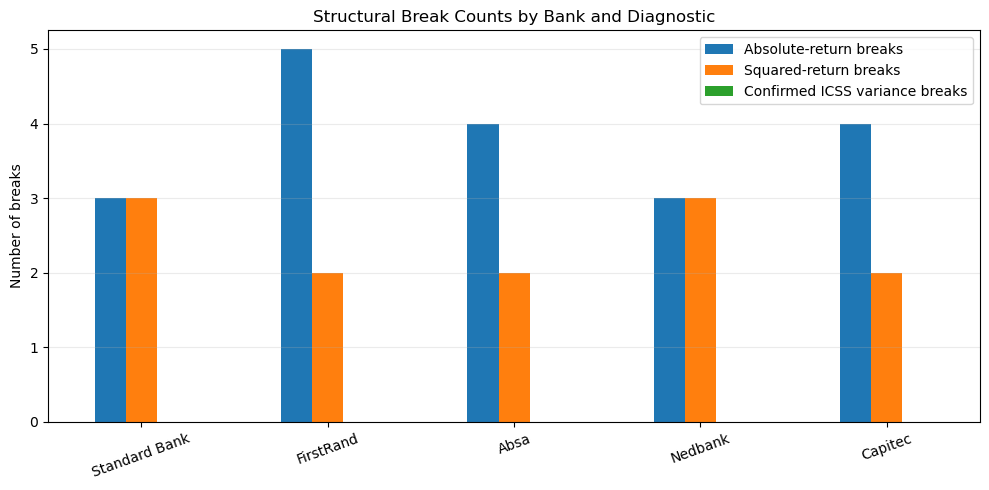

In [50]:
axis = (
    break_count_table
    .set_index("Bank")
    .plot(
        kind="bar",
        figsize=(10, 5),
    )
)

axis.set_title(
    "Structural Break Counts by Bank and Diagnostic"
)

axis.set_xlabel("")
axis.set_ylabel("Number of breaks")
axis.tick_params(axis="x", rotation=20)
axis.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()